<a href="https://colab.research.google.com/github/ayesha-tubassum/fdlkdjg/blob/main/decision_tree(online_shop_purchase).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DECISION TREE(online shopping purchases)**

---



# **Step 1 — Data Loading**

In [11]:
import pandas as pd
import numpy as np


In [12]:
df = pd.read_csv("/online_shoppers_intention.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


# **Step 2 — Data understanding**

In [13]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [15]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


# **Step 3 — Data Cleaning**

In [16]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 125


In [18]:
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (12205, 18)


In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# **Step 4 — Data Visualization (EDA)**

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
# Style
sns.set_style('whitegrid')

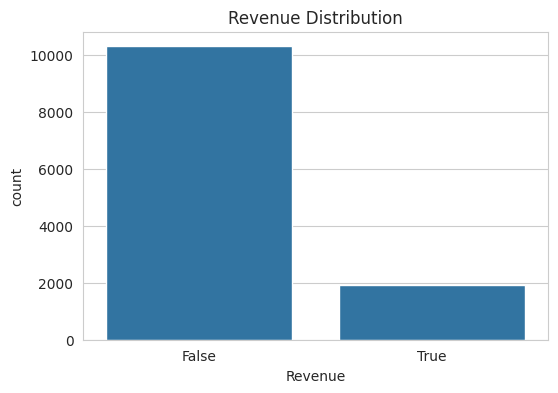

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='Revenue', data=df)

plt.title('Revenue Distribution')
plt.show()

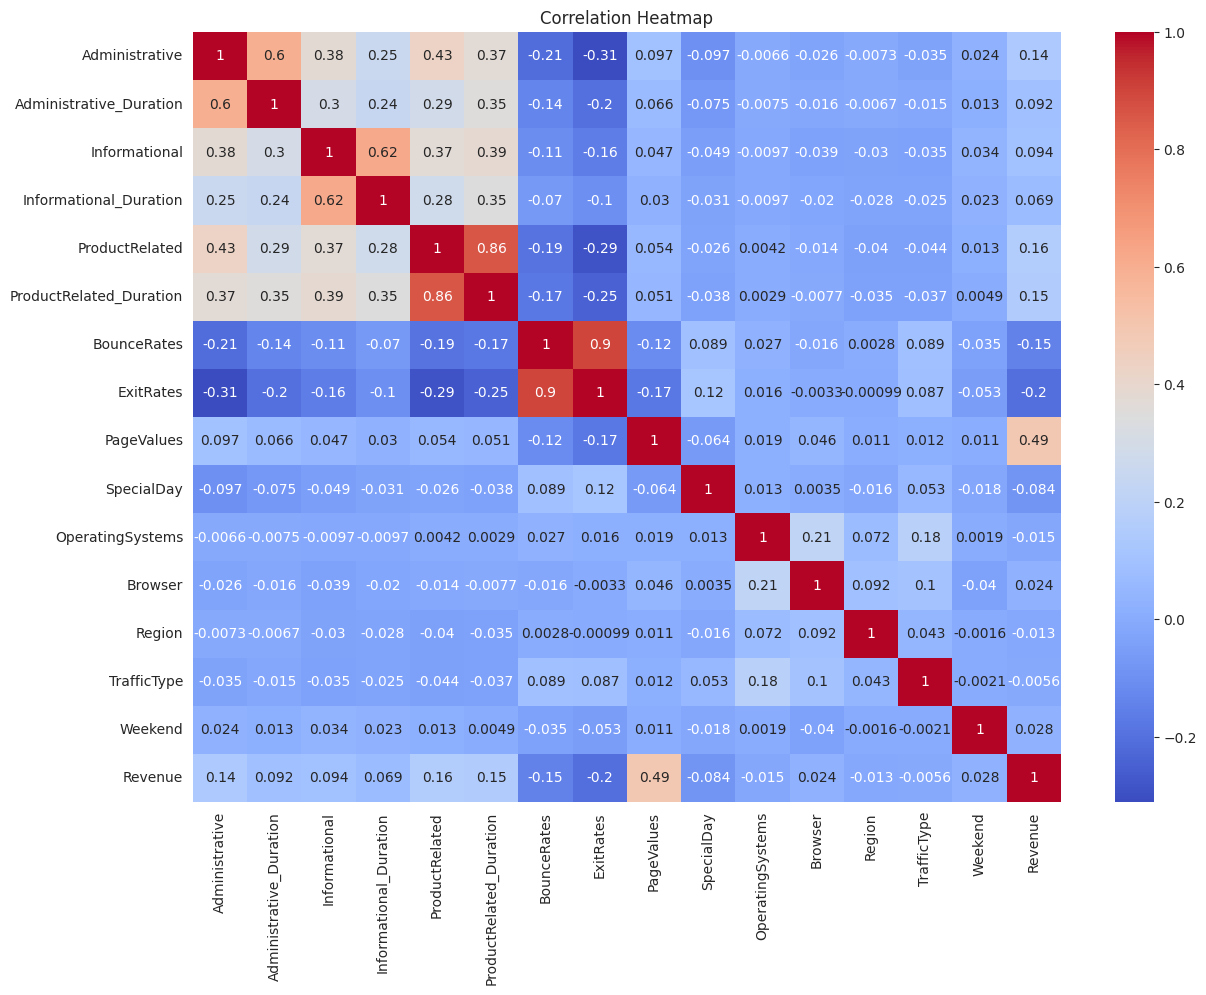

In [22]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

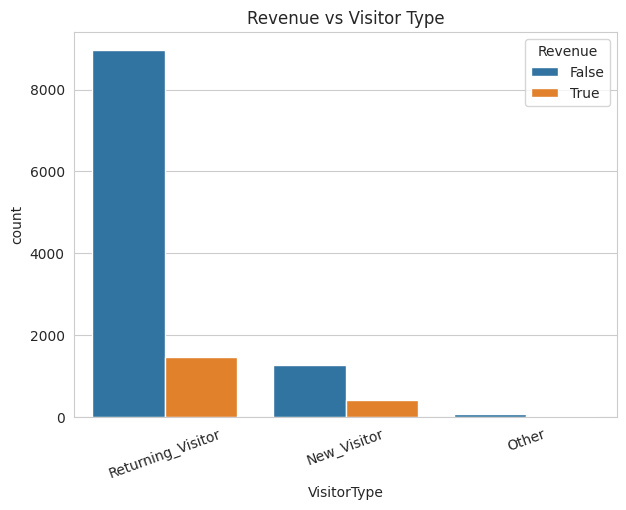

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(x='VisitorType', hue='Revenue', data=df)

plt.title('Revenue vs Visitor Type')
plt.xticks(rotation=20)
plt.show()

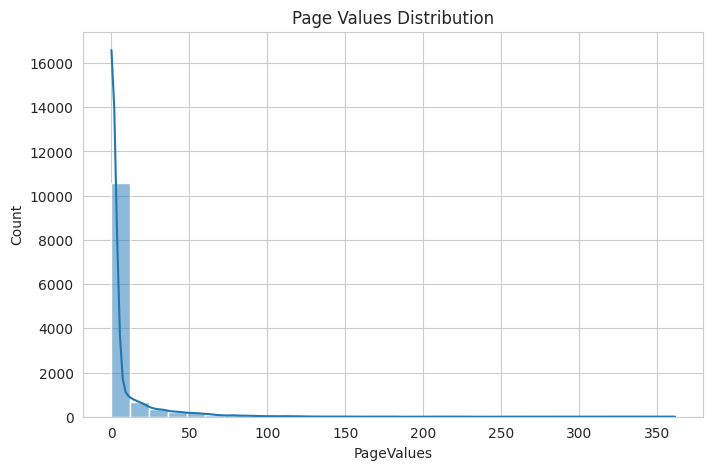

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['PageValues'], bins=30, kde=True)

plt.title('Page Values Distribution')
plt.show()

# **Step 5 — Feature Engineering**

In [29]:
from sklearn.preprocessing import LabelEncoder
df = df.copy()
# Convert Boolean to Integer
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
# Encode Only VisitorType
le = LabelEncoder()
df['VisitorType'] = le.fit_transform(df['VisitorType'])
print(df.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0      2                 1   
1         0.00       0.10         0.0         0.0      2

# **Step 6 — Define Features and Target**

In [32]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']
print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (12205, 17)
y Shape: (12205,)


# **Step 7 — Train Test Split**

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (9764, 17)
X_test Shape: (2441, 17)


# **Step 8 — Model Selection**

In [34]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
print(model)

DecisionTreeClassifier(random_state=42)


# **Step 9 — Model Training**

In [35]:
model.fit(X_train, y_train)
print("Model Training Completed")

Model Training Completed


# **Step 10 — Model Prediction**

In [36]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[0 0 0 1 0 0 0 0 0 0]


# **Step 11 — Model Evaluation**

In [37]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8713641950020483


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      2059
           1       0.59      0.60      0.59       382

    accuracy                           0.87      2441
   macro avg       0.76      0.76      0.76      2441
weighted avg       0.87      0.87      0.87      2441



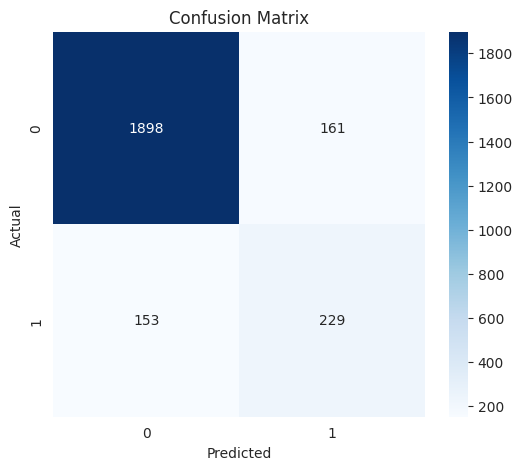

In [40]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Step 12 — Decision Tree Visualization**

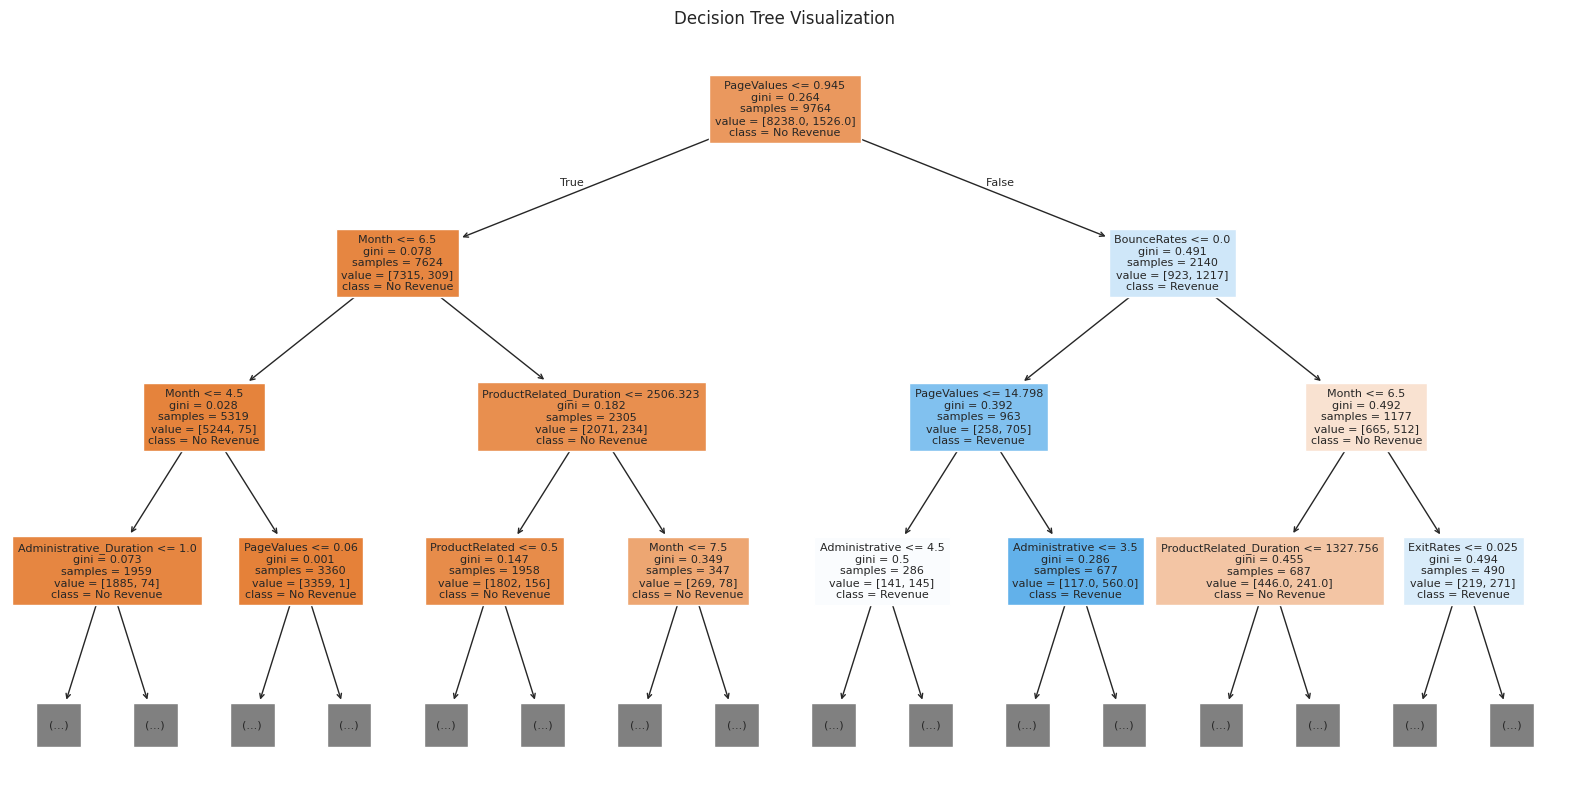

In [42]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No Revenue', 'Revenue'],
    max_depth=3,
    fontsize=8
)
plt.title('Decision Tree Visualization')
plt.show()

# **Step 13 — Model Tuning**

In [43]:
from sklearn.model_selection import GridSearchCV
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [44]:
# Best Model
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)

print("Tuned Model Accuracy:", best_accuracy)

Tuned Model Accuracy: 0.9000409668168783


# **Step 14 — Cross Validation**

In [45]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Score:", cv_scores.mean())

Cross Validation Scores:
[0.91356002 0.89471528 0.89102827 0.87546088 0.87095453]
Average CV Score: 0.889143793527243


# **Step 15 — Pipeline Building**

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
pipeline.fit(X_train, y_train)
pipeline_pred = pipeline.predict(X_test)
pipeline_accuracy = accuracy_score(y_test, pipeline_pred)

print("Pipeline Accuracy:", pipeline_accuracy)

Pipeline Accuracy: 0.8697255223269152


# **Step 16 — Final Model Summary**

In [47]:
print("Simple Decision Tree Accuracy:", accuracy)
print("Tuned Decision Tree Accuracy:", best_accuracy)
print("Pipeline Accuracy:", pipeline_accuracy)
print("Cross Validation Mean Accuracy:", cv_scores.mean())

Simple Decision Tree Accuracy: 0.8713641950020483
Tuned Decision Tree Accuracy: 0.9000409668168783
Pipeline Accuracy: 0.8697255223269152
Cross Validation Mean Accuracy: 0.889143793527243
